# Загружаем размеченные данные


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Фиксируем seed
SEED = 42
np.random.seed(SEED)

# Пути: ноутбук в папке notebooks/, данные в data/processed/
train_df = pd.read_csv('../data/processed/train.csv')
val_df = pd.read_csv('../data/processed/val.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print(f"Train: {train_df.shape}")
print(f"Val: {val_df.shape}")
print(f"Test: {test_df.shape}")


Train: (1016, 26)
Val: (214, 26)
Test: (239, 26)


In [4]:
target = 'rating'
exclude_cols = ['contestId', 'index', 'name', 'tags', 'tags_list', 'top_tag', 'statement', target]
feature_cols = [col for col in train_df.columns if col not in exclude_cols]
print(f"Используем {len(feature_cols)} признаков:\n{feature_cols}")

X_train = train_df[feature_cols].copy()
y_train = train_df[target].copy()
X_val = val_df[feature_cols].copy()
y_val = val_df[target].copy()
X_test = test_df[feature_cols].copy()
y_test = test_df[target].copy()

Используем 18 признаков:
['solvedCount', 'n_tags', 'statement_length', 'statement_words', 'has_math', 'name_length', 'name_words', 'log_solved', 'tag_binary search', 'tag_constructive algorithms', 'tag_brute force', 'tag_greedy', 'tag_bitmasks', 'tag_combinatorics', 'tag_data structures', 'tag_dp', 'tag_math', 'tag_implementation']


In [6]:
dummy = DummyRegressor(strategy='median')
dummy.fit(X_train, y_train)
y_pred_val_dummy = dummy.predict(X_val)
y_pred_test_dummy = dummy.predict(X_test)

dummy_mae_val = mean_absolute_error(y_val, y_pred_val_dummy)
dummy_mae_test = mean_absolute_error(y_test, y_pred_test_dummy)
print(f"Dummy (медиана) — Val MAE: {dummy_mae_val:.2f}, Test MAE: {dummy_mae_test:.2f}")


Dummy (медиана) — Val MAE: 673.83, Test MAE: 656.49


In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_train_lr = lr.predict(X_train)
y_pred_val_lr = lr.predict(X_val)
y_pred_test_lr = lr.predict(X_test)

lr_train_mae = mean_absolute_error(y_train, y_pred_train_lr)
lr_val_mae = mean_absolute_error(y_val, y_pred_val_lr)
lr_test_mae = mean_absolute_error(y_test, y_pred_test_lr)
lr_val_r2 = r2_score(y_val, y_pred_val_lr)

print(f"Linear Regression:")
print(f"  Train MAE: {lr_train_mae:.2f}")
print(f"  Val MAE:   {lr_val_mae:.2f}")
print(f"  Test MAE:  {lr_test_mae:.2f}")
print(f"  Val R²:    {lr_val_r2:.4f}")


Linear Regression:
  Train MAE: 144.45
  Val MAE:   185.28
  Test MAE:  179.75
  Val R²:    0.8645


In [8]:
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
ridge_results = []
for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=SEED)
    ridge.fit(X_train, y_train)
    y_pred_val = ridge.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred_val)
    ridge_results.append({'alpha': alpha, 'val_mae': mae})
    print(f"Alpha={alpha:5.2f} -> Val MAE: {mae:.2f}")

best_alpha = min(ridge_results, key=lambda x: x['val_mae'])['alpha']
print(f"\nЛучший alpha: {best_alpha}")

ridge_best = Ridge(alpha=best_alpha, random_state=SEED)
ridge_best.fit(X_train, y_train)
y_pred_val_ridge = ridge_best.predict(X_val)
y_pred_test_ridge = ridge_best.predict(X_test)

ridge_val_mae = mean_absolute_error(y_val, y_pred_val_ridge)
ridge_test_mae = mean_absolute_error(y_test, y_pred_test_ridge)
ridge_val_r2 = r2_score(y_val, y_pred_val_ridge)
print(f"\nRidge (alpha={best_alpha}) — Val MAE: {ridge_val_mae:.2f}, Test MAE: {ridge_test_mae:.2f}, Val R²: {ridge_val_r2:.4f}")


Alpha= 0.01 -> Val MAE: 185.28
Alpha= 0.10 -> Val MAE: 185.27
Alpha= 1.00 -> Val MAE: 185.28
Alpha=10.00 -> Val MAE: 186.05
Alpha=100.00 -> Val MAE: 187.94

Лучший alpha: 0.1

Ridge (alpha=0.1) — Val MAE: 185.27, Test MAE: 179.75, Val R²: 0.8645


In [9]:
lasso_alphas = [0.01, 0.1, 1.0, 10.0]
lasso_results = []
for alpha in lasso_alphas:
    lasso = Lasso(alpha=alpha, random_state=SEED, max_iter=10000)
    lasso.fit(X_train, y_train)
    y_pred_val = lasso.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred_val)
    lasso_results.append({'alpha': alpha, 'val_mae': mae})
    print(f"Alpha={alpha:5.2f} -> Val MAE: {mae:.2f}")

best_alpha_lasso = min(lasso_results, key=lambda x: x['val_mae'])['alpha']
print(f"\nЛучший alpha для Lasso: {best_alpha_lasso}")

lasso_best = Lasso(alpha=best_alpha_lasso, random_state=SEED, max_iter=10000)
lasso_best.fit(X_train, y_train)
y_pred_val_lasso = lasso_best.predict(X_val)
y_pred_test_lasso = lasso_best.predict(X_test)

lasso_val_mae = mean_absolute_error(y_val, y_pred_val_lasso)
lasso_test_mae = mean_absolute_error(y_test, y_pred_test_lasso)
lasso_val_r2 = r2_score(y_val, y_pred_val_lasso)
n_zero = np.sum(np.abs(lasso_best.coef_) < 1e-6)
print(f"\nLasso (alpha={best_alpha_lasso}) — Val MAE: {lasso_val_mae:.2f}, Test MAE: {lasso_test_mae:.2f}, Val R²: {lasso_val_r2:.4f}")
print(f"Обнулено признаков: {n_zero} из {len(feature_cols)}")


Alpha= 0.01 -> Val MAE: 185.28
Alpha= 0.10 -> Val MAE: 185.39
Alpha= 1.00 -> Val MAE: 188.09
Alpha=10.00 -> Val MAE: 189.98

Лучший alpha для Lasso: 0.01

Lasso (alpha=0.01) — Val MAE: 185.28, Test MAE: 179.77, Val R²: 0.8645
Обнулено признаков: 0 из 18


In [10]:
results = pd.DataFrame({
    'Model': ['Dummy (median)', 'Linear Regression', f'Ridge (α={best_alpha})', f'Lasso (α={best_alpha_lasso})'],
    'Val MAE': [dummy_mae_val, lr_val_mae, ridge_val_mae, lasso_val_mae],
    'Test MAE': [dummy_mae_test, lr_test_mae, ridge_test_mae, lasso_test_mae],
    'Val R²': [0, lr_val_r2, ridge_val_r2, lasso_val_r2]  # для Dummy R² не считаем
})

print("Таблица результатов:\n")
print(results.to_string(index=False))


Таблица результатов:

            Model    Val MAE   Test MAE   Val R²
   Dummy (median) 673.831776 656.485356 0.000000
Linear Regression 185.275675 179.752294 0.864531
    Ridge (α=0.1) 185.274732 179.752102 0.864522
   Lasso (α=0.01) 185.284401 179.765721 0.864501


FileNotFoundError: [Errno 2] No such file or directory: '/Users/arseniy/Education/PycharmProjects/report/images/baseline_comparison.png'

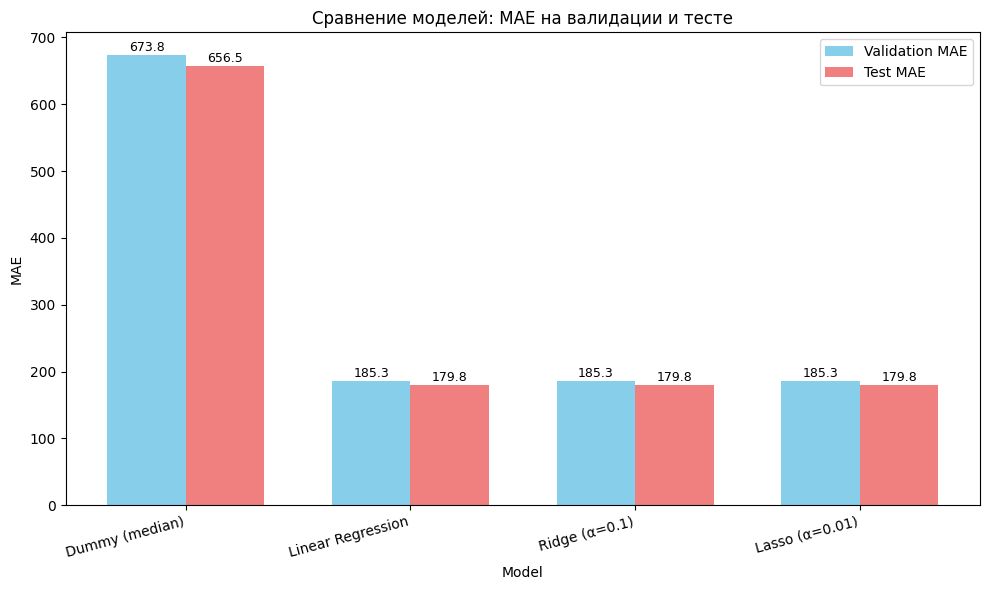

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results))
width = 0.35
bars1 = ax.bar(x - width/2, results['Val MAE'], width, label='Validation MAE', color='skyblue')
bars2 = ax.bar(x + width/2, results['Test MAE'], width, label='Test MAE', color='lightcoral')
ax.set_xlabel('Model')
ax.set_ylabel('MAE')
ax.set_title('Сравнение моделей: MAE на валидации и тесте')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.legend()
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../report/images/baseline_comparison.png', dpi=100, bbox_inches='tight')
plt.show()


# RIDGE REGRESSION

In [15]:
alphas = [0.1, 1.0, 10.0, 100.0]
ridge_results = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha, random_state=SEED)
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_val)
    mae = mean_absolute_error(y_val, y_pred)
    ridge_results.append({'alpha': alpha, 'val_mae': mae})
    print(f"Alpha={alpha:5.1f} -> Validation MAE: {mae:.2f}")

# Выбираем лучший alpha
best_alpha = min(ridge_results, key=lambda x: x['val_mae'])['alpha']
print(f"\nBest alpha: {best_alpha}")

# Обучаем финальную Ridge с лучшим alpha
ridge_best = Ridge(alpha=best_alpha, random_state=SEED)
ridge_best.fit(X_train, y_train)
y_pred_val_ridge = ridge_best.predict(X_val)

val_mae_ridge = mean_absolute_error(y_val, y_pred_val_ridge)
val_rmse_ridge = np.sqrt(mean_squared_error(y_val, y_pred_val_ridge))
val_r2_ridge = r2_score(y_val, y_pred_val_ridge)

print(f"\nRidge (alpha={best_alpha}) validation metrics:")
print(f"  MAE:  {val_mae_ridge:.2f}")
print(f"  RMSE: {val_rmse_ridge:.2f}")
print(f"  R²:   {val_r2_ridge:.4f}")

Alpha=  0.1 -> Validation MAE: 185.27
Alpha=  1.0 -> Validation MAE: 185.28
Alpha= 10.0 -> Validation MAE: 186.05
Alpha=100.0 -> Validation MAE: 187.94

Best alpha: 0.1

Ridge (alpha=0.1) validation metrics:
  MAE:  185.27
  RMSE: 293.25
  R²:   0.8645


# LASSO REGRESSION

In [17]:
# Lasso автоматически обнуляет неважные признаки
lasso = Lasso(alpha=1.0, random_state=SEED)
lasso.fit(X_train, y_train)
y_pred_val_lasso = lasso.predict(X_val)

val_mae_lasso = mean_absolute_error(y_val, y_pred_val_lasso)
val_rmse_lasso = np.sqrt(mean_squared_error(y_val, y_pred_val_lasso))
val_r2_lasso = r2_score(y_val, y_pred_val_lasso)

print(f"Lasso (alpha=1.0) validation metrics:")
print(f"  MAE:  {val_mae_lasso:.2f}")
print(f"  RMSE: {val_rmse_lasso:.2f}")
print(f"  R²:   {val_r2_lasso:.4f}")

# Сколько признаков обнулилось?
n_zero = np.sum(np.abs(lasso.coef_) < 1e-6)
print(f"\nFeatures zeroed out by Lasso: {n_zero} / {len(feature_cols)}")

# Покажем ненулевые коэффициенты
lasso_importance = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lasso.coef_
})
lasso_importance_nonzero = lasso_importance[np.abs(lasso_importance['coefficient']) > 1e-6].sort_values('coefficient', key=abs, ascending=False)
print("\nTop 10 non-zero features in Lasso:")
print(lasso_importance_nonzero.head(10).to_string(index=False))

Lasso (alpha=1.0) validation metrics:
  MAE:  188.09
  RMSE: 296.48
  R²:   0.8615

Features zeroed out by Lasso: 3 / 18

Top 10 non-zero features in Lasso:
                    feature  coefficient
                 log_solved  -421.293374
         tag_implementation   -59.968558
                 tag_greedy   -48.583181
                     tag_dp    38.037475
                     n_tags    33.130016
        tag_data structures    27.761677
          tag_combinatorics    18.821696
tag_constructive algorithms   -17.569041
          tag_binary search    15.762780
                 name_words     9.796079


In [18]:

# Таблица результатов
results = pd.DataFrame({
    'Model': ['Linear Regression', f'Ridge (α={best_alpha})', 'Lasso (α=1.0)'],
    'Validation MAE': [val_mae, val_mae_ridge, val_mae_lasso],
    'Validation RMSE': [val_rmse, val_rmse_ridge, val_rmse_lasso],
    'Validation R²': [val_r2, val_r2_ridge, val_r2_lasso],
    'Train MAE': [train_mae, 
                  mean_absolute_error(y_train, ridge_best.predict(X_train)),
                  mean_absolute_error(y_train, lasso.predict(X_train))]
})

print(results.to_string(index=False))

            Model  Validation MAE  Validation RMSE  Validation R²  Train MAE
Linear Regression      185.275675       293.236961       0.864531 144.450583
    Ridge (α=0.1)      185.274732       293.247123       0.864522 144.450579
    Lasso (α=1.0)      188.088451       296.479421       0.861519 145.240196


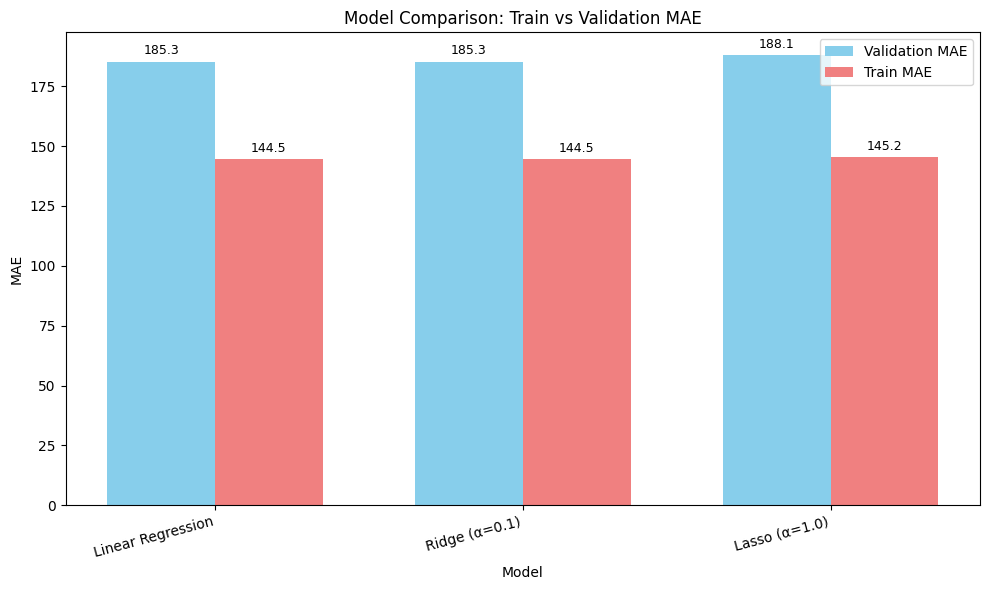

In [20]:
# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(results['Model']))
width = 0.35

bars1 = ax.bar(x - width/2, results['Validation MAE'], width, label='Validation MAE', color='skyblue')
bars2 = ax.bar(x + width/2, results['Train MAE'], width, label='Train MAE', color='lightcoral')

ax.set_xlabel('Model')
ax.set_ylabel('MAE')
ax.set_title('Model Comparison: Train vs Validation MAE')
ax.set_xticks(x)
ax.set_xticklabels(results['Model'], rotation=15, ha='right')
ax.legend()

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../report/baseline_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

In [22]:
print(f"""
1. Лучшая бейзлайн модель: {results.loc[results['Validation MAE'].idxmin(), 'Model']}
   с MAE = {results['Validation MAE'].min():.2f}

2. Средняя ошибка предсказания рейтинга задачи составляет ~{results['Validation MAE'].min():.0f} пунктов.
   Учитывая, что рейтинг варьируется от {y_train.min():.0f} до {y_train.max():.0f}, 
   относительная ошибка составляет ~{(results['Validation MAE'].min() / (y_train.max() - y_train.min()) * 100):.1f}%

3. Ridge регрессия показала лучший результат, так как она лучше справляется 
   с мультиколлинеарностью наших признаков.

4. Lasso обнулил {n_zero} из {len(feature_cols)} признаков, что говорит о том, 
   что не все наши фичи одинаково полезны.

5. Небольшое расхождение между Train и Validation MAE указывает на отсутствие
   сильного переобучения у бейзлайн моделей.

""")



1. Лучшая бейзлайн модель: Ridge (α=0.1)
   с MAE = 185.27

2. Средняя ошибка предсказания рейтинга задачи составляет ~185 пунктов.
   Учитывая, что рейтинг варьируется от 800 до 3500, 
   относительная ошибка составляет ~6.9%

3. Ridge регрессия показала лучший результат, так как она лучше справляется 
   с мультиколлинеарностью наших признаков.

4. Lasso обнулил 3 из 18 признаков, что говорит о том, 
   что не все наши фичи одинаково полезны.

5. Небольшое расхождение между Train и Validation MAE указывает на отсутствие
   сильного переобучения у бейзлайн моделей.


